In [45]:
import pandas as pd


train = pd.read_csv("train_dataset.csv")
train

,Uniprot ID,molecule ID,evidence,Binding,type,substrate ID
0,G8BBN0,CHEBI:35681,exp,1.0,NaN,CHEBI:35681
1,P78937,CHEBI:30616,exp,1.0,NaN,CHEBI:30616
2,F4K688,CHEBI:30616,exp,1.0,NaN,CHEBI:30616
3,Q9Z0J5,CHEBI:58349,exp,1.0,NaN,CHEBI:58349
4,P49189,CHEBI:58264,exp,1.0,NaN,CHEBI:58264
...,...,...,...,...,...,...
55873,Q9NS84,CHEBI:30616,NaN,0.0,NaN,CHEBI:30616
55874,Q9NS84,C00002,NaN,0.0,NaN,C00002
55875,Q03649,CHEBI:17815,NaN,0.0,NaN,CHEBI:17815
55876,Q03649,CHEBI:35681,NaN,0.0,NaN,CHEBI:35681


In [46]:
import numpy as np

indices_train = np.load("CV_train_indices.npy", allow_pickle=True)
indices_train = indices_train.tolist()
indices_valid = np.load("CV_test_indices.npy", allow_pickle=True)
indices_valid = indices_valid.tolist()

for i in range(0, len(indices_train)):
    train.loc[indices_train[i], f"kfold_{i}"] = "train"
    train.loc[indices_valid[i], f"kfold_{i}"] = "valid"


In [47]:
train

,Uniprot ID,molecule ID,evidence,Binding,type,substrate ID,kfold_0,kfold_1,kfold_2,kfold_3,kfold_4
0,G8BBN0,CHEBI:35681,exp,1.0,NaN,CHEBI:35681,valid,train,train,train,train
1,P78937,CHEBI:30616,exp,1.0,NaN,CHEBI:30616,train,valid,train,train,train
2,F4K688,CHEBI:30616,exp,1.0,NaN,CHEBI:30616,train,train,valid,train,train
3,Q9Z0J5,CHEBI:58349,exp,1.0,NaN,CHEBI:58349,train,train,train,valid,train
4,P49189,CHEBI:58264,exp,1.0,NaN,CHEBI:58264,train,train,train,train,valid
...,...,...,...,...,...,...,...,...,...,...,...
55873,Q9NS84,CHEBI:30616,NaN,0.0,NaN,CHEBI:30616,train,train,valid,train,train
55874,Q9NS84,C00002,NaN,0.0,NaN,C00002,train,train,valid,train,train
55875,Q03649,CHEBI:17815,NaN,0.0,NaN,CHEBI:17815,train,valid,train,train,train
55876,Q03649,CHEBI:35681,NaN,0.0,NaN,CHEBI:35681,train,valid,train,train,train


In [48]:
test = pd.read_csv("test_dataset.csv")
test

,Uniprot ID,molecule ID,evidence,Binding,type,substrate ID
0,P9WJI9,CHEBI:57502,exp,1,NaN,CHEBI:57502
1,O88491,C00019,exp,1,NaN,C00019
2,P00815,CHEBI:73183,exp,1,NaN,CHEBI:73183
3,P51635,CHEBI:17587,exp,1,NaN,CHEBI:17587
4,Q19905,CHEBI:58885,exp,1,NaN,CHEBI:58885
...,...,...,...,...,...,...
13454,P00812,CHEBI:57405,NaN,0,NaN,CHEBI:57405
13455,P00812,CHEBI:52639,NaN,0,NaN,CHEBI:52639
13456,P77161,CHEBI:17815,NaN,0,NaN,CHEBI:17815
13457,P77161,CHEBI:15562,NaN,0,NaN,CHEBI:15562


In [9]:
merged = pd.concat((train, test), axis=0)

In [10]:
merged

,Uniprot ID,molecule ID,evidence,Binding,type,substrate ID,kfold_0,kfold_1,kfold_2,kfold_3,kfold_4
0,G8BBN0,CHEBI:35681,exp,1.0,NaN,CHEBI:35681,valid,train,train,train,train
1,P78937,CHEBI:30616,exp,1.0,NaN,CHEBI:30616,train,valid,train,train,train
2,F4K688,CHEBI:30616,exp,1.0,NaN,CHEBI:30616,train,train,valid,train,train
3,Q9Z0J5,CHEBI:58349,exp,1.0,NaN,CHEBI:58349,train,train,train,valid,train
4,P49189,CHEBI:58264,exp,1.0,NaN,CHEBI:58264,train,train,train,train,valid
...,...,...,...,...,...,...,...,...,...,...,...
13454,P00812,CHEBI:57405,NaN,0.0,NaN,CHEBI:57405,NaN,NaN,NaN,NaN,NaN
13455,P00812,CHEBI:52639,NaN,0.0,NaN,CHEBI:52639,NaN,NaN,NaN,NaN,NaN
13456,P77161,CHEBI:17815,NaN,0.0,NaN,CHEBI:17815,NaN,NaN,NaN,NaN,NaN
13457,P77161,CHEBI:15562,NaN,0.0,NaN,CHEBI:15562,NaN,NaN,NaN,NaN,NaN


In [11]:
merged.drop(columns=["type", "substrate ID"], inplace=True)

In [12]:
from Bio import SeqIO

# Path to your FASTA file
fasta_file1 = "UNIPROT_IDs_V3.fasta"
fasta_file2 = "UNIPROT_IDs_V2.fasta"
fasta_file3 = "UNIPROT_IDs_V1.fasta"
fasta_file4 = "V4.fasta"

sequences = {}

for fasta_file in [fasta_file1, fasta_file2, fasta_file3, fasta_file4]:
    # Read the FASTA file
    for record in SeqIO.parse(fasta_file, "fasta"):
        id_ = record.id.split('|')[1]
        sequence = str(record.seq)

        sequences[id_] = sequence



In [13]:
protein_sequences = pd.DataFrame({"Uniprot ID": sequences.keys(),
                                  "sequence": sequences.values()})

In [14]:
len(sequences)

217977

In [15]:
chebi = pd.read_csv("chebiID_to_inchi.tsv", sep="\t")
chebi

,Input,Result,BioCyc Common-Name,BioCyc,Kegg,ChEBI,PubChem,HMDB,ChemSpider,MetaboLights,MetaNetX,BiGG,Seed,Inchi
0,ChEBI:132511,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ChEBI:11805,success,3-hydroxy-isobutanoate,3-HYDROXY-ISOBUTYRATE,C01188,11805.0,11966314,HMDB62640,,,MNXM396,,cpd00876,"InChI=1S/C4H8O3/c1-3(2-5)4(6)7/h3,5H,2H2,1H3,(..."
2,ChEBI:17568,success,uracil,URACIL,C00106,17568.0,1174,HMDB00300,1141,MTBLC17568,MNXM158,ura,cpd00092,"InChI=1S/C4H4N2O2/c7-3-1-2-5-4(8)6-3/h1-2H,(H2..."
3,ChEBI:17237,success,crotono-betaine,CROTONO-BETAINE,C04114,17237.0,5462194,,4575319,,MNXM1607,ctbt,cpd02543,"InChI=1S/C7H13NO2/c1-8(2,3)6-4-5-7(9)10/h4-5H,..."
4,ChEBI:35121,success,"(2R,3S)-3-isopropylmalate",2-D-THREO-HYDROXY-3-CARBOXY-ISOCAPROATE,C04411,35121.0,6857402,HMDB12156,5256741,,MNXM891,3c2hmp,cpd02693,InChI=1S/C7H12O5/c1-3(2)4(6(9)10)5(8)7(11)12/h...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1497,ChEBI:62877,success,2-deoxy-D-ribose 5-phosphate,DEOXY-RIBOSE-5P,C00673,62877.0,53477568,HMDB01031,,,MNXM2179,2dr5p,,"InChI=1S/C5H11O7P/c6-3-1-5(7)12-4(3)2-11-13(8,..."
1498,ChEBI:58763,success,N2-succinylglutamate,N2-SUCCINYLGLUTAMATE,C05931,58763.0,25244383,,,,MNXM1757,sucglu,cpd03525,InChI=1S/C9H13NO7/c11-6(2-4-8(14)15)10-5(9(16)...
1499,ChEBI:57986,success,riboflavin,RIBOFLAVIN,C00255,57986.0,45480541,HMDB00244,108964,,MNXM270,ribflv,cpd00220,InChI=1S/C17H20N4O6/c1-7-3-9-10(4-8(7)2)21(5-1...
1500,ChEBI:57743,success,L-citrulline,L-CITRULLINE,C00327,57743.0,6992098,HMDB00904,,MTBLC16349,MNXM211,citr__L,cpd00274,InChI=1S/C6H13N3O3/c7-4(5(10)11)2-1-3-9-6(8)12...


In [17]:
substrate_dict = {}

import io

from Bio.KEGG import REST as kegg_api
import pandas as pd

from rdkit import Chem
import urllib

def get_compound_inchi(compound_id):
    try:
        structure = kegg_api.kegg_get(compound_id, option='mol').read()
    except urllib.error.HTTPError:
        structure = None

    if structure is not None:
        mol = Chem.MolFromMolBlock(structure)

        if mol is not None:
            smiles = Chem.MolToSmiles(mol)
            return smiles
        
    return None

for substrate in merged.loc[:, "molecule ID"].unique(): 
    inchi = chebi[chebi["Input"].str.upper() == substrate].Inchi.values
    if inchi: 
        substrate_dict[substrate] = Chem.MolToSmiles(Chem.MolFromInchi(inchi[0]))
    else:
        substrate_dict[substrate] = get_compound_inchi(substrate)

/tmp/ipykernel_3687582/20209677.py:28: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if inchi:
[17:26:18] Cannot assign bond directions!
[17:26:30] WARNING:  Problems/mismatches: Mobile-H( Proton balance: Does not match)

[17:26:31] WARNING: not removing hydrogen atom without neighbors
[17:26:41] WARNING: not removing hydrogen atom without neighbors
[17:27:42] Cannot assign bond directions!
[17:28:50] WARNING:  Problems/mismatches: Mobile-H( Proton balance: Does not match)

[17:30:39] Cannot assign bond directions!
[17:30:39] WARNING:  Problems/mismatches: Mobile-H( Hydrogens: Number; Mobile-H groups: Number; Charge(s): Do not match)

[17:31:38] Cannot assign bond directions!


In [18]:
subtrate_smiles = pd.DataFrame({"molecule ID": substrate_dict.keys(),
              "smiles": substrate_dict.values()})

In [19]:
subtrate_smiles

,molecule ID,smiles
0,CHEBI:35681,CC(C)O
1,CHEBI:30616,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...
2,CHEBI:58349,N=C([O-])c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(...
3,CHEBI:58264,[NH3+]CCCC=O
4,C00002,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...
...,...,...
1347,CHEBI:48999,O=C(O)Cc1ccc([O-])cc1
1348,CHEBI:58318,N=C(O)NCCCC[NH3+]
1349,CHEBI:71685,O=C([O-])C(=O)C[C@H](O)C(=O)[O-]
1350,C00049,N[C@@H](CC(=O)O)C(=O)O


In [20]:
subtrate_smiles[pd.isna(subtrate_smiles["smiles"])]

,molecule ID,smiles
520,C15778,None


In [21]:
subtrate_smiles.to_csv("substrate_smiles.csv", index=False)

In [22]:
subtrate_smiles = pd.read_csv("substrate_smiles.csv")

In [23]:
subtrate_smiles

,molecule ID,smiles
0,CHEBI:35681,CC(C)O
1,CHEBI:30616,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...
2,CHEBI:58349,N=C([O-])c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(...
3,CHEBI:58264,[NH3+]CCCC=O
4,C00002,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...
...,...,...
1347,CHEBI:48999,O=C(O)Cc1ccc([O-])cc1
1348,CHEBI:58318,N=C(O)NCCCC[NH3+]
1349,CHEBI:71685,O=C([O-])C(=O)C[C@H](O)C(=O)[O-]
1350,C00049,N[C@@H](CC(=O)O)C(=O)O


In [24]:
merged

,Uniprot ID,molecule ID,evidence,Binding,kfold_0,kfold_1,kfold_2,kfold_3,kfold_4
0,G8BBN0,CHEBI:35681,exp,1.0,valid,train,train,train,train
1,P78937,CHEBI:30616,exp,1.0,train,valid,train,train,train
2,F4K688,CHEBI:30616,exp,1.0,train,train,valid,train,train
3,Q9Z0J5,CHEBI:58349,exp,1.0,train,train,train,valid,train
4,P49189,CHEBI:58264,exp,1.0,train,train,train,train,valid
...,...,...,...,...,...,...,...,...,...
13454,P00812,CHEBI:57405,NaN,0.0,NaN,NaN,NaN,NaN,NaN
13455,P00812,CHEBI:52639,NaN,0.0,NaN,NaN,NaN,NaN,NaN
13456,P77161,CHEBI:17815,NaN,0.0,NaN,NaN,NaN,NaN,NaN
13457,P77161,CHEBI:15562,NaN,0.0,NaN,NaN,NaN,NaN,NaN


In [25]:
merged = pd.merge(merged, subtrate_smiles, on="molecule ID")

In [26]:
merged = pd.merge(merged, protein_sequences, on="Uniprot ID")

In [27]:
merged = merged[~pd.isna(merged["smiles"])]

In [28]:
merged.to_csv("merged_dataset_with_representation.csv", index=False)

In [49]:
import pandas as pd

merged = pd.read_csv("merged_dataset_with_representation.csv")
merged

,Uniprot ID,molecule ID,evidence,Binding,kfold_0,kfold_1,kfold_2,kfold_3,kfold_4,smiles,sequence
0,G8BBN0,CHEBI:35681,exp,1.0,valid,train,train,train,train,CC(C)O,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...
1,G8BBN0,CHEBI:30616,NaN,0.0,valid,train,train,train,train,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...
2,G8BBN0,CHEBI:58349,exp,1.0,valid,train,train,train,train,N=C([O-])c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(...,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...
3,G8BBN0,C00019,NaN,0.0,valid,train,train,train,train,C[S+](CC[C@H](N)C(=O)[O-])C[C@H]1O[C@@H](n2cnc...,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...
4,G8BBN0,CHEBI:59789,NaN,0.0,valid,train,train,train,train,C[S@@+](CC[C@H](N)C(=O)O)C[C@H]1O[C@@H](n2cnc3...,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...
...,...,...,...,...,...,...,...,...,...,...,...
68138,P0AAB4,CHEBI:1617,exp,1.0,NaN,NaN,NaN,NaN,NaN,CC(C)=CCC/C(C)=C/CC/C(C)=C/CC/C(C)=C/CC/C(C)=C...,MDAMKYNDLRDFLTLLEQQGELKRITLPVDPHLEITEIADRTLRAG...
68139,O29537,CHEBI:57871,NaN,0.0,NaN,NaN,NaN,NaN,NaN,COc1ccc2c3c1O[C@H]1[C@@H](O)C=C[C@H]4[C@@H](C2...,MRRGLVIVGHGSQLNHYREVMELHRKRIEESGAFDEVKIAFAARKR...
68140,O29537,CHEBI:60049,exp,1.0,NaN,NaN,NaN,NaN,NaN,C[C@@]1(CC(=O)[O-])c2cc3nc(cc4[n-]c(cc5[n-]c(c...,MRRGLVIVGHGSQLNHYREVMELHRKRIEESGAFDEVKIAFAARKR...
68141,O29537,CHEBI:60491,NaN,0.0,NaN,NaN,NaN,NaN,NaN,C=Cc1c(C)c2cc3nc(cc4nc(cc5[nH]c(cc1[n-]2)c(C)c...,MRRGLVIVGHGSQLNHYREVMELHRKRIEESGAFDEVKIAFAARKR...


In [50]:
merged = merged.loc[:, ["Uniprot ID", "molecule ID", "smiles", "sequence", "kfold_0", "kfold_1", "kfold_2", "kfold_3", "kfold_4"]]
merged

,Uniprot ID,molecule ID,smiles,sequence,kfold_0,kfold_1,kfold_2,kfold_3,kfold_4
0,G8BBN0,CHEBI:35681,CC(C)O,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...,valid,train,train,train,train
1,G8BBN0,CHEBI:30616,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...,valid,train,train,train,train
2,G8BBN0,CHEBI:58349,N=C([O-])c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(...,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...,valid,train,train,train,train
3,G8BBN0,C00019,C[S+](CC[C@H](N)C(=O)[O-])C[C@H]1O[C@@H](n2cnc...,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...,valid,train,train,train,train
4,G8BBN0,CHEBI:59789,C[S@@+](CC[C@H](N)C(=O)O)C[C@H]1O[C@@H](n2cnc3...,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...,valid,train,train,train,train
...,...,...,...,...,...,...,...,...,...
68138,P0AAB4,CHEBI:1617,CC(C)=CCC/C(C)=C/CC/C(C)=C/CC/C(C)=C/CC/C(C)=C...,MDAMKYNDLRDFLTLLEQQGELKRITLPVDPHLEITEIADRTLRAG...,NaN,NaN,NaN,NaN,NaN
68139,O29537,CHEBI:57871,COc1ccc2c3c1O[C@H]1[C@@H](O)C=C[C@H]4[C@@H](C2...,MRRGLVIVGHGSQLNHYREVMELHRKRIEESGAFDEVKIAFAARKR...,NaN,NaN,NaN,NaN,NaN
68140,O29537,CHEBI:60049,C[C@@]1(CC(=O)[O-])c2cc3nc(cc4[n-]c(cc5[n-]c(c...,MRRGLVIVGHGSQLNHYREVMELHRKRIEESGAFDEVKIAFAARKR...,NaN,NaN,NaN,NaN,NaN
68141,O29537,CHEBI:60491,C=Cc1c(C)c2cc3nc(cc4nc(cc5[nH]c(cc1[n-]2)c(C)c...,MRRGLVIVGHGSQLNHYREVMELHRKRIEESGAFDEVKIAFAARKR...,NaN,NaN,NaN,NaN,NaN


In [53]:
import pandas as pd


train = pd.read_csv("train_dataset.csv")
train

,Uniprot ID,molecule ID,evidence,Binding,type,substrate ID
0,G8BBN0,CHEBI:35681,exp,1.0,NaN,CHEBI:35681
1,P78937,CHEBI:30616,exp,1.0,NaN,CHEBI:30616
2,F4K688,CHEBI:30616,exp,1.0,NaN,CHEBI:30616
3,Q9Z0J5,CHEBI:58349,exp,1.0,NaN,CHEBI:58349
4,P49189,CHEBI:58264,exp,1.0,NaN,CHEBI:58264
...,...,...,...,...,...,...
55873,Q9NS84,CHEBI:30616,NaN,0.0,NaN,CHEBI:30616
55874,Q9NS84,C00002,NaN,0.0,NaN,C00002
55875,Q03649,CHEBI:17815,NaN,0.0,NaN,CHEBI:17815
55876,Q03649,CHEBI:35681,NaN,0.0,NaN,CHEBI:35681


In [54]:
train = pd.merge(train, merged, how="left", on=["Uniprot ID", "molecule ID"]).drop_duplicates(subset=["Uniprot ID", "molecule ID"])

In [55]:
train = train.dropna(subset="smiles")

In [56]:
train

,Uniprot ID,molecule ID,evidence,Binding,type,substrate ID,smiles,sequence,kfold_0,kfold_1,kfold_2,kfold_3,kfold_4
0,G8BBN0,CHEBI:35681,exp,1.0,NaN,CHEBI:35681,CC(C)O,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...,valid,train,train,train,train
1,P78937,CHEBI:30616,exp,1.0,NaN,CHEBI:30616,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...,MTKALLKDLNARDAPLREQLEQEATSLPKIVLSERQFCDVELILNG...,train,valid,train,train,train
2,F4K688,CHEBI:30616,exp,1.0,NaN,CHEBI:30616,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...,MDVPLPVEKLSYGSNTEDKTCVVLVATGSFNPPTFMHLRMFELARD...,train,train,valid,train,train
3,Q9Z0J5,CHEBI:58349,exp,1.0,NaN,CHEBI:58349,N=C([O-])c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(...,MAAIVAALRGSSGRFRPQTRVLTRGTRGAAGAASAAGGQQNFDLLV...,train,train,train,valid,train
4,P49189,CHEBI:58264,exp,1.0,NaN,CHEBI:58264,[NH3+]CCCC=O,MSTGTFVVSQPLNYRGGARVEPADASGTEKAFEPATGRVIATFTCS...,train,train,train,train,valid
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63614,O77475,CHEBI:30616,NaN,0.0,NaN,CHEBI:30616,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...,MIGPSSQISKILLTLLFLLIIFYVFMDVELYLRIHNYAIERNYHTN...,valid,train,train,train,train
63620,Q9NS84,CHEBI:30616,NaN,0.0,NaN,CHEBI:30616,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...,MKGRRRRRREYCKFALLLVLYTLVLLLVPSVLDGGRDGDKGAEHCP...,train,train,valid,train,train
63623,Q03649,CHEBI:17815,NaN,0.0,NaN,CHEBI:17815,O=COC[C@H](CO)OC=O,MRLKELLPNFLIVHQEVPEDPIAFKSTDKRENENKEITIPELIDTK...,train,valid,train,train,train
63624,Q03649,CHEBI:35681,NaN,0.0,NaN,CHEBI:35681,CC(C)O,MRLKELLPNFLIVHQEVPEDPIAFKSTDKRENENKEITIPELIDTK...,train,valid,train,train,train


In [57]:
train.to_csv("train_dataset_w_representation.csv", index=True, index_label="Index")

In [58]:
test = pd.merge(test, merged, how="left", on=["Uniprot ID", "molecule ID"]).drop_duplicates(subset=["Uniprot ID", "molecule ID"])

In [59]:
test = test.dropna(subset="smiles")

In [60]:
test

,Uniprot ID,molecule ID,evidence,Binding,type,substrate ID,smiles,sequence,kfold_0,kfold_1,kfold_2,kfold_3,kfold_4
0,P9WJI9,CHEBI:57502,exp,1,NaN,CHEBI:57502,O=C([O-])c1ccc[n+]([C@@H]2O[C@H](COP(=O)([O-])...,MGPPPAARRREGEPDNQDPAGLLTDKYELTMLAAALRDGSANRPTT...,NaN,NaN,NaN,NaN,NaN
1,O88491,C00019,exp,1,NaN,C00019,C[S+](CC[C@H](N)C(=O)[O-])C[C@H]1O[C@@H](n2cnc...,MDRTCELSRRNCLLSFSNPVNLDASEDKDSPFGNGQSNFSEPLNGC...,NaN,NaN,NaN,NaN,NaN
2,P00815,CHEBI:73183,exp,1,NaN,CHEBI:73183,N=c1c2ncn([C@@H]3O[C@H](COP(=O)([O-])OP(=O)([O...,MVLPILPLIDDLASWNSKKEYVSLVGQVLLDGSSLSNEEILQFSKE...,NaN,NaN,NaN,NaN,NaN
3,P51635,CHEBI:17587,exp,1,NaN,CHEBI:17587,O=C1O[C@H]([C@@H](O)CO)[C@H](O)[C@@H]1O,MTASSVLLHTGQKMPLIGLGTWKSEPGQVKAAIKYALSVGYRHIDC...,NaN,NaN,NaN,NaN,NaN
4,Q19905,CHEBI:58885,exp,1,NaN,CHEBI:58885,O=c1nc([O-])ccn1[C@@H]1O[C@H](COP(=O)([O-])OP(...,MTDQVFGKVSKVVCVGAGYVGGPTCAMIAHKCPHITVTVVDMNTAK...,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15750,P00812,CHEBI:57405,NaN,0,NaN,CHEBI:57405,CCCCC[C@H](O)/C=C/[C@@H]1[C@@H](C/C=C\CCCC(=O)...,METGPHYNYYKNRELSIVLAPFSGGQGKLGVEKGPKYMLKHGLQTS...,NaN,NaN,NaN,NaN,NaN
15751,P00812,CHEBI:52639,NaN,0,NaN,CHEBI:52639,CCCCCCCCCCCCC/C=C/[C@@H](O)[C@H](CO)N=CO,METGPHYNYYKNRELSIVLAPFSGGQGKLGVEKGPKYMLKHGLQTS...,NaN,NaN,NaN,NaN,NaN
15752,P77161,CHEBI:17815,NaN,0,NaN,CHEBI:17815,O=COC[C@H](CO)OC=O,MKLGFIGLGIMGTPMAINLARAGHQLHVTTIGPVADELLSLGAVSV...,NaN,NaN,NaN,NaN,NaN
15753,P77161,CHEBI:15562,NaN,0,NaN,CHEBI:15562,O=C([O-])C[C@H](C(=O)[O-])[C@@H](O)C(=O)[O-],MKLGFIGLGIMGTPMAINLARAGHQLHVTTIGPVADELLSLGAVSV...,NaN,NaN,NaN,NaN,NaN


In [61]:
test.to_csv("test_dataset_w_representation.csv", index=True, index_label="Index")

In [62]:
test.Binding.value_counts()

0    9335
1    3427
Name: Binding, dtype: int64

In [63]:
train.Binding.value_counts()

0.0    39081
1.0    14325
Name: Binding, dtype: int64

In [16]:
train.drop_duplicates(subset=["Uniprot ID", "molecule ID"])

,Uniprot ID,molecule ID,evidence,Binding,type,substrate ID
0,G8BBN0,CHEBI:35681,exp,1.0,NaN,CHEBI:35681
1,P78937,CHEBI:30616,exp,1.0,NaN,CHEBI:30616
2,F4K688,CHEBI:30616,exp,1.0,NaN,CHEBI:30616
3,Q9Z0J5,CHEBI:58349,exp,1.0,NaN,CHEBI:58349
4,P49189,CHEBI:58264,exp,1.0,NaN,CHEBI:58264
...,...,...,...,...,...,...
55870,O77475,CHEBI:30616,NaN,0.0,NaN,CHEBI:30616
55873,Q9NS84,CHEBI:30616,NaN,0.0,NaN,CHEBI:30616
55875,Q03649,CHEBI:17815,NaN,0.0,NaN,CHEBI:17815
55876,Q03649,CHEBI:35681,NaN,0.0,NaN,CHEBI:35681


In [ ]:
len(merged.loc[:, "Uniprot ID"].unique())

12020

In [26]:
len(substrate_dict)

1033

In [13]:
pd.read_pickle("KEGG_substrate_df.pkl")

,KEGG ID,substrate
0,C00001,H2O
1,C00001,Water
2,C00002,ATP
3,C00002,Adenosine 5'-triphosphate
4,C00003,NAD+
...,...,...
31124,C22242,3-O-Methyl-D-rhamnose
31125,C22243,L-Acofriose
31126,C22243,3-O-Methyl-L-rhamnose
31127,C22244,Ascarylose


In [ ]:
from plants_sm.data_structures.dataset.multi_input_dataset import MultiInputDataset
# load datasets

train_dataset = MultiInputDataset.from_csv("merged_dataset_with_representation.csv", representation_field={"compounds": "smiles", 
                                                                                      "proteins": "sequence"},
                                                                                      instances_ids_field={"compounds": "molecule ID", 
                                                                                      "proteins": "Uniprot ID"})

In [5]:

from plants_sm.featurization.proteins.bio_embeddings.esm import ESMEncoder
from plants_sm.data_standardization.proteins.standardization import ProteinStandardizer
from plants_sm.data_standardization.truncation import Truncator

truncator = Truncator(max_length=884)
protein_standardizer = ProteinStandardizer()
transformer = ESMEncoder(esm_function="esm2_t36_3B_UR50D", batch_size=1, num_gpus=4)

multi_input_dataset = protein_standardizer.fit_transform(train_dataset, "proteins")
multi_input_dataset = truncator.fit_transform(train_dataset, "proteins")
multi_input_dataset = transformer.fit_transform(train_dataset, "proteins")


ESM:   0%|          | 0/11 [00:00<?, ?it/s]/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/fairscale/nn/data_parallel/fully_sharded_data_parallel.py:2562: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  if data.storage().size() > 0:
ESM: 100%|██████████| 11/11 [00:16<00:00,  1.52s/it]


In [6]:
multi_input_dataset.save_features("features_proteins")

In [7]:
multi_input_dataset.load_features("features_proteins", "proteins")

# Validation split

In [10]:
import pandas as pd

train_dataset = pd.read_csv("train_dataset_w_representation.csv")

In [11]:
train_dataset

,Index,Uniprot ID,molecule ID,evidence,Binding,type,substrate ID,smiles,sequence
0,0,G8BBN0,CHEBI:35681,exp,1.0,NaN,CHEBI:35681,CC(C)O,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...
1,1,P78937,CHEBI:30616,exp,1.0,NaN,CHEBI:30616,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...,MTKALLKDLNARDAPLREQLEQEATSLPKIVLSERQFCDVELILNG...
2,2,F4K688,CHEBI:30616,exp,1.0,NaN,CHEBI:30616,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...,MDVPLPVEKLSYGSNTEDKTCVVLVATGSFNPPTFMHLRMFELARD...
3,3,Q9Z0J5,CHEBI:58349,exp,1.0,NaN,CHEBI:58349,N=C([O-])c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(...,MAAIVAALRGSSGRFRPQTRVLTRGTRGAAGAASAAGGQQNFDLLV...
4,4,P49189,CHEBI:58264,exp,1.0,NaN,CHEBI:58264,[NH3+]CCCC=O,MSTGTFVVSQPLNYRGGARVEPADASGTEKAFEPATGRVIATFTCS...
...,...,...,...,...,...,...,...,...,...
53401,63614,O77475,CHEBI:30616,NaN,0.0,NaN,CHEBI:30616,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...,MIGPSSQISKILLTLLFLLIIFYVFMDVELYLRIHNYAIERNYHTN...
53402,63620,Q9NS84,CHEBI:30616,NaN,0.0,NaN,CHEBI:30616,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...,MKGRRRRRREYCKFALLLVLYTLVLLLVPSVLDGGRDGDKGAEHCP...
53403,63623,Q03649,CHEBI:17815,NaN,0.0,NaN,CHEBI:17815,O=COC[C@H](CO)OC=O,MRLKELLPNFLIVHQEVPEDPIAFKSTDKRENENKEITIPELIDTK...
53404,63624,Q03649,CHEBI:35681,NaN,0.0,NaN,CHEBI:35681,CC(C)O,MRLKELLPNFLIVHQEVPEDPIAFKSTDKRENENKEITIPELIDTK...


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(train_dataset, train_dataset.Binding,
                                                    stratify=train_dataset.Binding, 
                                                    test_size=0.12)

In [13]:
X_train.sample(frac=1, random_state=123).to_csv("train_dataset_w_representation_split.csv", index=False)

In [14]:
X_test.sample(frac=1, random_state=123).to_csv("validation_dataset_w_representation.csv", index=False)

In [2]:
import pandas as pd

merged_dataset = pd.read_csv("merged_dataset_with_representation.csv")
merged_dataset

,Uniprot ID,molecule ID,evidence,Binding,smiles,sequence
0,G8BBN0,CHEBI:35681,exp,1.0,CC(C)O,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...
1,G8BBN0,CHEBI:30616,NaN,0.0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...
2,G8BBN0,CHEBI:58349,exp,1.0,N=C([O-])c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(...,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...
3,G8BBN0,C00019,NaN,0.0,C[S+](CC[C@H](N)C(=O)[O-])C[C@H]1O[C@@H](n2cnc...,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...
4,G8BBN0,CHEBI:59789,NaN,0.0,C[S@@+](CC[C@H](N)C(=O)O)C[C@H]1O[C@@H](n2cnc3...,MSIPSSQYGFVFNKQSGLNLRNDLPVHKPKAGQLLLKVDAVGLCHS...
...,...,...,...,...,...,...
68138,P0AAB4,CHEBI:1617,exp,1.0,CC(C)=CCC/C(C)=C/CC/C(C)=C/CC/C(C)=C/CC/C(C)=C...,MDAMKYNDLRDFLTLLEQQGELKRITLPVDPHLEITEIADRTLRAG...
68139,O29537,CHEBI:57871,NaN,0.0,COc1ccc2c3c1O[C@H]1[C@@H](O)C=C[C@H]4[C@@H](C2...,MRRGLVIVGHGSQLNHYREVMELHRKRIEESGAFDEVKIAFAARKR...
68140,O29537,CHEBI:60049,exp,1.0,C[C@@]1(CC(=O)[O-])c2cc3nc(cc4[n-]c(cc5[n-]c(c...,MRRGLVIVGHGSQLNHYREVMELHRKRIEESGAFDEVKIAFAARKR...
68141,O29537,CHEBI:60491,NaN,0.0,C=Cc1c(C)c2cc3nc(cc4nc(cc5[nH]c(cc1[n-]2)c(C)c...,MRRGLVIVGHGSQLNHYREVMELHRKRIEESGAFDEVKIAFAARKR...


In [4]:
merged_dataset.drop_duplicates(subset="molecule ID").to_csv("unique_compounds.csv", index=False)

In [5]:
import os
from deepmol.loaders import CSVLoader
from deepmol.compound_featurization import ThreeDimensionalMoleculeGenerator

# Processing parameters
timeout = 200
threads = 50
n_conformations = 1
max_iterations = 100
etkdg_version = 3
mode = "MMFF94"

dataset = CSVLoader("unique_compounds.csv", id_field="molecule ID", smiles_field="smiles").create_dataset()
            
# Generate 3D conformers
generator = ThreeDimensionalMoleculeGenerator(
    timeout_per_molecule=timeout, threads=threads,
    n_conformations=n_conformations, max_iterations=max_iterations
)
generator.generate(dataset, etkdg_version=etkdg_version, mode=mode)

# Save as SDF
output_sdf_path = os.path.join("unique_compounds_conformers.sdf")
dataset.to_sdf(output_sdf_path)

/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-03-13 22:38:22.281959: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-13 22:38:22.285736: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-13 22:38:22.330698: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-13 22:38:22.330731: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609

In [7]:
from deepmol.loaders import SDFLoader

dataset = SDFLoader("unique_compounds_conformers.sdf", id_field="_ID").create_dataset()

[22:45:44] WARNING: not removing hydrogen atom without neighbors
[22:45:45] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 8 ignored
[22:45:45] Warning: ambiguous stereochemistry - linear bond arrangement - at atom 11 ignored
[22:45:45] Warning: ambiguous stereochemistry - linear bond arrangement - at atom 5 ignored


In [8]:
dataset.get_shape()

2025-03-13 22:45:56,828 — INFO — Mols_shape: (1351,)
2025-03-13 22:45:56,830 — INFO — Features_shape: None
2025-03-13 22:45:56,830 — INFO — Labels_shape: None


((1351,), None, None)

In [9]:
counts = 0

for mol in dataset.mols:
    # Attempt to get the first conformer (3D coordinates)
    conformer = mol.GetConformer()
    if conformer is not None:
        counts+=1

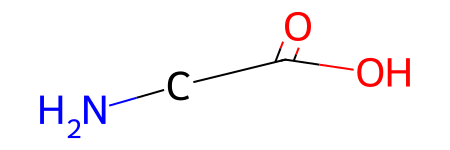

In [14]:
dataset.mols[93]

# Test dataset for gat

In [7]:
from deepmol.loaders import SDFLoader

dataset = SDFLoader("unique_compounds_conformers.sdf", id_field="_ID").create_dataset()

[14:40:56] WARNING: not removing hydrogen atom without neighbors
[14:40:56] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 8 ignored
[14:40:56] Warning: ambiguous stereochemistry - linear bond arrangement - at atom 11 ignored
[14:40:56] Warning: ambiguous stereochemistry - linear bond arrangement - at atom 5 ignored


In [8]:
dataset.get_shape()

2025-03-22 14:41:03,797 — INFO — Mols_shape: (1351,)
2025-03-22 14:41:03,798 — INFO — Features_shape: None
2025-03-22 14:41:03,798 — INFO — Labels_shape: None


((1351,), None, None)

In [ ]:
from deepmol.compound_featurization import All3DDescriptors, MixedFeaturizer, TwoDimensionDescriptors

MixedFeaturizer([All3DDescriptors(mandatory_generation_of_conformers=False), TwoDimensionDescriptors()]).featurize(dataset, inplace=True)

In [12]:
dataset.X.shape

(1287, 849)

In [11]:
from deepmol.scalers.sklearn_scalers import RobustScaler

dataset = RobustScaler().fit_transform(dataset)

In [13]:
dataset.X

array([[-0.8312412725481281, 3.3303170504311517, 2.288674866106836, ...,
        -0.26061457870521326, -0.3030584641529645, -0.30818057051573056],
       [0.7198911800244064, -0.5309200912481542, -0.5092524629049328,
        ..., 1.1355184050709026, 1.3135477584405706, 1.683066095657142],
       [0.10570830149635767, -0.7541478609730112, -0.8142117501975094,
        ..., 5.70907905887045, 5.768082465903493, 6.231355770990212],
       ...,
       [-0.7621090625416027, -0.21719457461047845, -0.29311622830634704,
        ..., 0.3379314059235692, 0.26675702529424306, 0.4521967984983387],
       [-0.36755296888276545, -0.042232275899219955,
        -0.023686206210274507, ..., -0.06049774272006298,
        -0.04431819438241507, 0.024796127785367553],
       [0.5511948215612017, -0.4886878153489342, -0.5033309113523641,
        ..., 1.3455600752264205, 1.3243620521101662, 0.8071235130967166]],
      dtype=object)

In [2]:
molecules_dict = dict(zip(list(dataset.ids), list(dataset.mols)))

In [3]:
from plants_sm.io.pickle import read_pickle

enzymes_dict = read_pickle("features_proteins_esm2_3b/features.pkl")["enzymes"]

In [4]:
import pandas as pd

train_dataset = pd.read_csv("train_dataset_w_representation.csv")

In [5]:
interaction = list(zip(list(train_dataset["Uniprot ID"]), list(train_dataset["molecule ID"])))
labels = list(train_dataset["Binding"])

In [6]:

from copy import copy
from enzyme_substrate_prediction.models.structural_gat import MolecularGraphDataset, collate_fn
from torch.utils.data import Dataset, DataLoader

dataset = MolecularGraphDataset(copy(molecules_dict), enzymes_dict, interaction, labels)
dataloader = DataLoader(dataset, batch_size=56, shuffle=True, collate_fn=collate_fn)

/home/jcapela/enzyme-substrate-interaction/src/enzyme_substrate_prediction/models/structural_gat.py:82: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:261.)
  node_features = torch.tensor(node_features, dtype=torch.float32)


In [7]:
import pandas as pd

validation_dataset = pd.read_csv("validation_dataset_w_representation.csv")
interaction = list(zip(list(validation_dataset["Uniprot ID"]), list(validation_dataset["molecule ID"])))
labels = list(validation_dataset["Binding"])

from enzyme_substrate_prediction.models.structural_gat import MolecularGraphDataset, collate_fn
from torch.utils.data import Dataset, DataLoader

validation_dataset = MolecularGraphDataset(molecules_dict, enzymes_dict, interaction, labels)
val_dataloader = DataLoader(validation_dataset, batch_size=56, shuffle=True, collate_fn=collate_fn)

In [1]:
from enzyme_substrate_prediction.models.structural_gat import MolecularGAT3D
from pytorch_lightning import Trainer

model = MolecularGAT3D(in_dim=10, hidden_dim=1024, num_heads=8, batch_size=28)

/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from enzyme_substrate_prediction.models.structural_gat import MolecularGAT3D
from pytorch_lightning import Trainer

model = MolecularGAT3D(in_dim=10, hidden_dim=1024, num_heads=8, batch_size=28)
trainer = Trainer(max_epochs=10)
trainer.fit(model, dataloader, val_dataloaders=val_dataloader)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
2025-03-20 17:19:30.489902: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-20 17:19:30.493368: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-20 17:19:30.533762: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:475: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 9: 100%|██████████| 954/954 [01:02<00:00, 15.28it/s, v_num=16, train_loss_step=0.364, train_accuracy_step=0.842, train_f1_step=0.500, train_recall_step=0.375, train_precision_step=0.750, val_loss=0.359, val_accuracy=0.835, val_f1=0.554, val_recall=0.435, val_precision=0.832, train_loss_epoch=0.405, train_accuracy_epoch=0.815, train_f1_epoch=0.535, train_recall_epoch=0.430, train_precision_epoch=0.756]         

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 954/954 [01:03<00:00, 15.10it/s, v_num=16, train_loss_step=0.364, train_accuracy_step=0.842, train_f1_step=0.500, train_recall_step=0.375, train_precision_step=0.750, val_loss=0.359, val_accuracy=0.835, val_f1=0.554, val_recall=0.435, val_precision=0.832, train_loss_epoch=0.405, train_accuracy_epoch=0.815, train_f1_epoch=0.535, train_recall_epoch=0.430, train_precision_epoch=0.756]


In [1]:
from enzyme_substrate_prediction.models.structural_gat import get_three_d_descriptors

from deepmol.loaders import SDFLoader

dataset = SDFLoader("unique_compounds_conformers.sdf", id_field="_ID").create_dataset()
get_three_d_descriptors(dataset.mols[0])

/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[18:18:53] WARNING: not removing hydrogen atom without neighbors
[18:18:54] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 8 ignored
[18:18:54] Warning: ambiguous stereochemistry - linear bond arrangement - at atom 11 ignored
[18:18:54] Warning: ambiguous stereochemistry - linear bond arrangement - at atom 5 ignored


{'PMI1': 40.27079993008798,
 'PMI2': 42.39292713047719,
 'PMI3': 78.41872929877294,
 'NPR1': 0.513535481768105,
 'NPR2': 0.5405969659232993,
 'RadiusOfGyration': 1.2441532093155152,
 'InertialShapeFactor': 0.013424043397742317,
 'Eccentricity': 0.8580683591446548,
 'Asphericity': 0.21255382782115825,
 'SpherocityIndex': 0.08449577266354161,
 'PBF': 0.1800011306977225}

In [2]:
get_three_d_descriptors(dataset.mols[1])

{'PMI1': 1365.9754524835932,
 'PMI2': 13066.040686821012,
 'PMI3': 13404.017119978036,
 'NPR1': 0.1019079161311778,
 'NPR2': 0.9747854370721978,
 'RadiusOfGyration': 5.323828404355852,
 'InertialShapeFactor': 0.0007136185612266016,
 'Eccentricity': 0.9947938362443752,
 'Asphericity': 0.7276817778383227,
 'SpherocityIndex': 0.1192178022865408,
 'PBF': 0.8103020168099213}

In [23]:
from enzyme_substrate_prediction.models.structural_gat import MolecularGAT3D

model = MolecularGAT3D.load_from_checkpoint("molecular_gat_3d")

/home/jcapela/miniconda3/envs/esp/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'activation_attention' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['activation_attention'])`.


In [24]:
from pytorch_lightning import Trainer

trainer = Trainer(devices=[0])

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [25]:
from deepmol.loaders import SDFLoader

dataset = SDFLoader("unique_compounds_conformers.sdf", id_field="_ID").create_dataset()

molecules_dict = dict(zip(list(dataset.ids), list(dataset.mols)))

from plants_sm.io.pickle import read_pickle

enzymes_dict = read_pickle("features_proteins_esm2_3b/features.pkl")["enzymes"]

[16:57:27] WARNING: not removing hydrogen atom without neighbors
[16:57:27] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 8 ignored
[16:57:27] Warning: ambiguous stereochemistry - linear bond arrangement - at atom 11 ignored
[16:57:27] Warning: ambiguous stereochemistry - linear bond arrangement - at atom 5 ignored


In [26]:
import pandas as pd 

test_dataset = pd.read_csv("test_dataset_w_representation.csv")
interaction = list(zip(list(test_dataset["Uniprot ID"]), list(test_dataset["molecule ID"])))
labels = list(test_dataset["Binding"])

from enzyme_substrate_prediction.models.structural_gat import MolecularGraphDataset, collate_fn
from torch.utils.data import Dataset, DataLoader

test_dataset = MolecularGraphDataset(molecules_dict, enzymes_dict, interaction, labels)
test_dataloader = DataLoader(test_dataset, batch_size=56, shuffle=False, collate_fn=collate_fn)

In [34]:
trainer.test(model, test_dataloader)

2025-03-21 17:01:02.090886: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-21 17:01:02.094686: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-21 17:01:02.135155: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-21 17:01:02.135178: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-21 17:01:02.135213: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

Testing DataLoader 0: 100%|██████████| 228/228 [00:03<00:00, 68.95it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.8433631062507629
        test_loss            0.442048579454422
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.442048579454422, 'test_acc': 0.8433631062507629}]

In [42]:
import torch

# Iterate through the DataLoader
indices = []
predictions_list = []
model.eval()
y_true = []

for batched_data in test_dataloader:
    # Perform your model's forward pass
    predictions = model(batched_data)
    predictions_list.extend(list(predictions.reshape(predictions.shape[0], ).detach().numpy()))
    indices.extend(list(batched_data.idx.numpy()))
    y_true.extend(list(batched_data.y.numpy()))


In [43]:
import numpy as np

# Zip the predictions with their corresponding indices
paired = list(zip(indices, predictions_list))

# Sort the pairs based on the indices
paired_sorted = sorted(paired, key=lambda x: x[0])

# Extract the sorted predictions
sorted_predictions = np.array([pred for _, pred in paired_sorted])

In [53]:
binary_array = (np.array(predictions_list) >= 0.5).astype(int)

In [54]:
binary_array

array([1, 1, 0, ..., 0, 0, 0])

In [55]:
from sklearn.metrics import roc_auc_score, accuracy_score


roc_auc_score(y_true, predictions_list)

0.9119585266106106

In [56]:
accuracy_score(y_true, binary_array)

0.8414041686256073

In [4]:
from plants_sm.io.pickle import read_pickle, write_pickle

features = read_pickle("features_proteins_esm2_3b/features.pkl")


new_features = {}
new_features["proteins"] = features["enzymes"]
write_pickle("features_proteins_esm2_3b/features.pkl", new_features)

True